Mini-projet : Analyse de données pour la stratégie marketing


Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

Chargement des données

In [2]:
file_path = r"C:\Users\home\Desktop\DI-Bootcamp\Week2\Day5\MiniProjet\US Superstore data (1).xls"
df = pd.read_excel(file_path)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Exploration initiale

In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Nettoyage des données

In [4]:
# Nettoyage des colonnes
df.columns = df.columns.str.strip()
# Conversion des dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
# Colonnes utiles
df["Year"] = df["Order Date"].dt.year
df["Profit Margin"] = df["Profit"] / df["Sales"]

États avec le plus de ventes

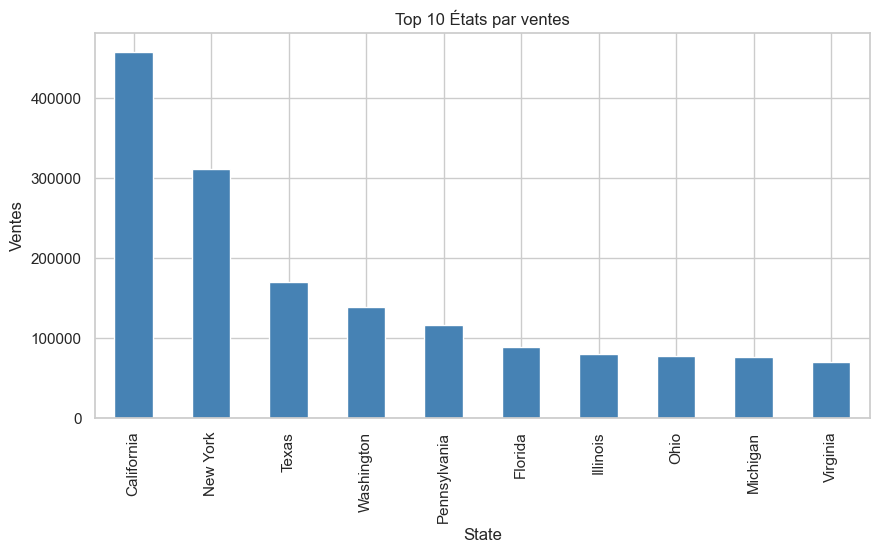

In [5]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales.head(10).plot(kind="bar", color="steelblue")
plt.title("Top 10 États par ventes")
plt.ylabel("Ventes")
plt.show()

New York vs Californie

In [6]:
ny_ca = df[df["State"].isin(["New York", "California"])] \
    .groupby("State")[["Sales", "Profit"]].sum()
ny_ca

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


Visualisation

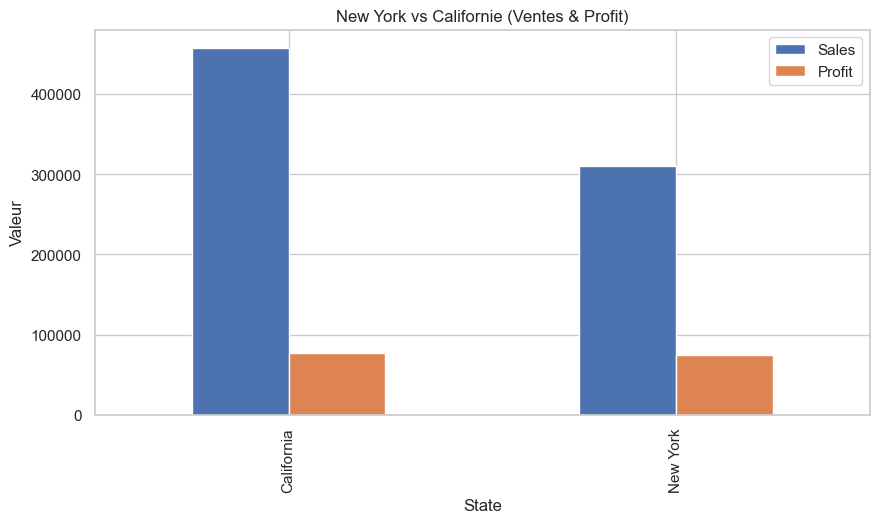

In [7]:
ny_ca.plot(kind="bar")
plt.title("New York vs Californie (Ventes & Profit)")
plt.ylabel("Valeur")
plt.show()

Client le plus rentable à New York

In [8]:
ny_top_customer = df[df["State"] == "New York"] \
    .groupby("Customer Name")["Profit"] \
    .sum().sort_values(ascending=False)
ny_top_customer.head(10)

Customer Name
Tom Ashbrook        4599.2073
Keith Dawkins       2510.8903
Karen Daniels       2283.0463
Nathan Mautz        2247.1904
Tom Boeckenhauer    2239.9872
Steven Roelle       1863.9614
Pete Kriz           1695.3209
Darrin Martin       1599.6806
Todd Sumrall        1574.9714
Seth Vernon         1571.7964
Name: Profit, dtype: float64

Rentabilité par État

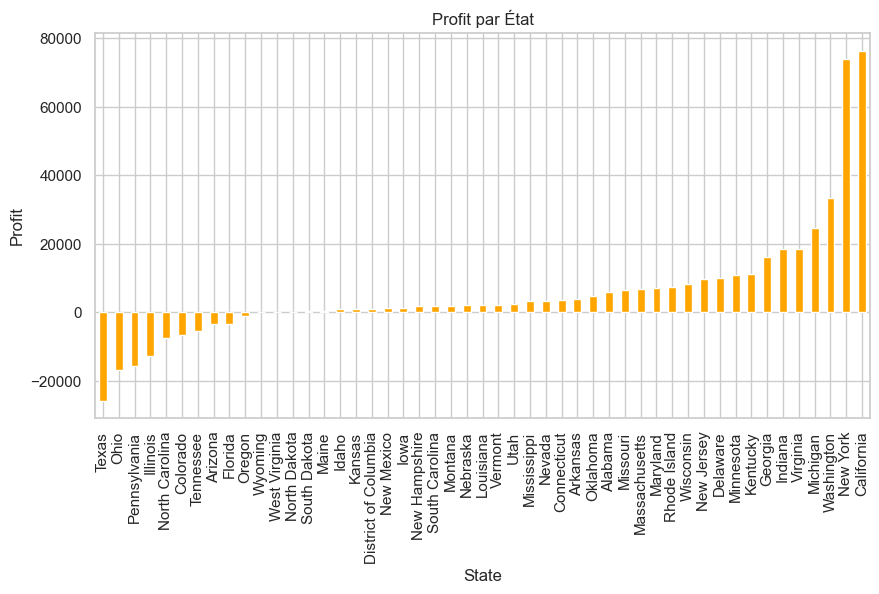

In [9]:
state_profit = df.groupby("State")["Profit"].sum().sort_values()
state_profit.plot(kind="bar", color="orange")
plt.title("Profit par État")
plt.ylabel("Profit")
plt.show()

Analyse Pareto (Clients vs Profit)

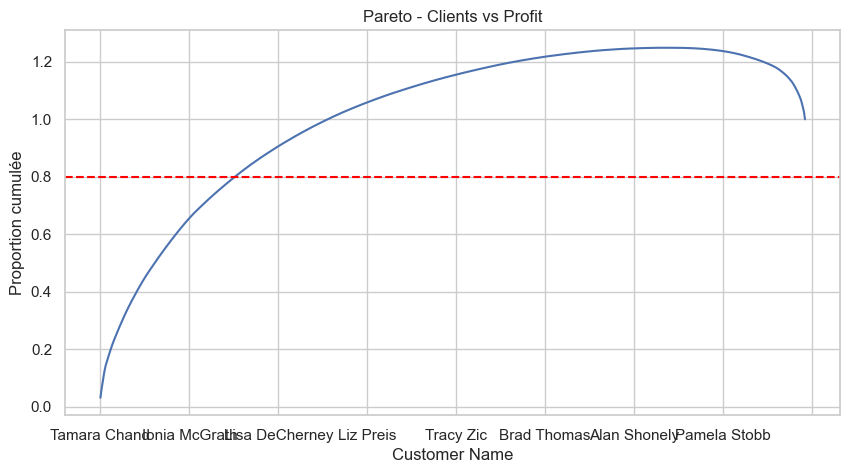

In [10]:
customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)
cum_profit = customer_profit.cumsum() / customer_profit.sum()
cum_profit.plot()
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Pareto - Clients vs Profit")
plt.ylabel("Proportion cumulée")
plt.show()

Top 20 villes (Ventes)

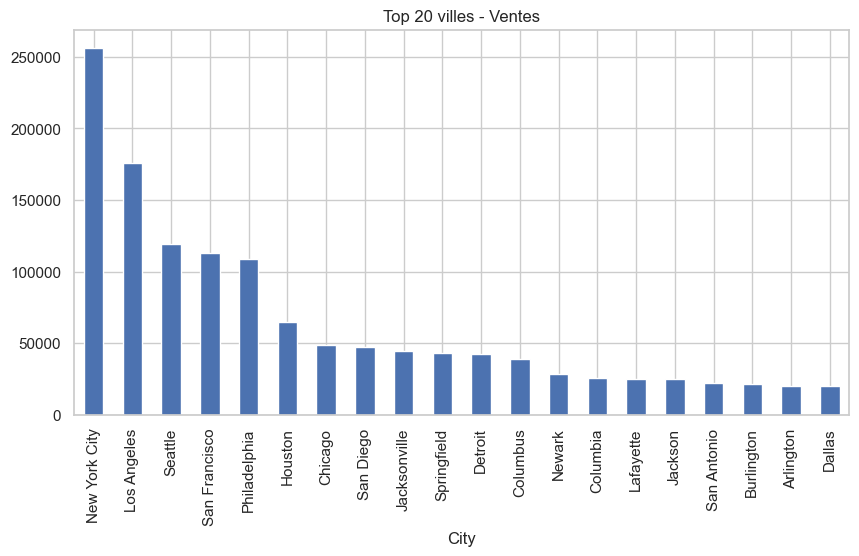

In [11]:
top_cities_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)
top_cities_sales.plot(kind="bar")
plt.title("Top 20 villes - Ventes")
plt.show()

Top 20 villes (Profit)

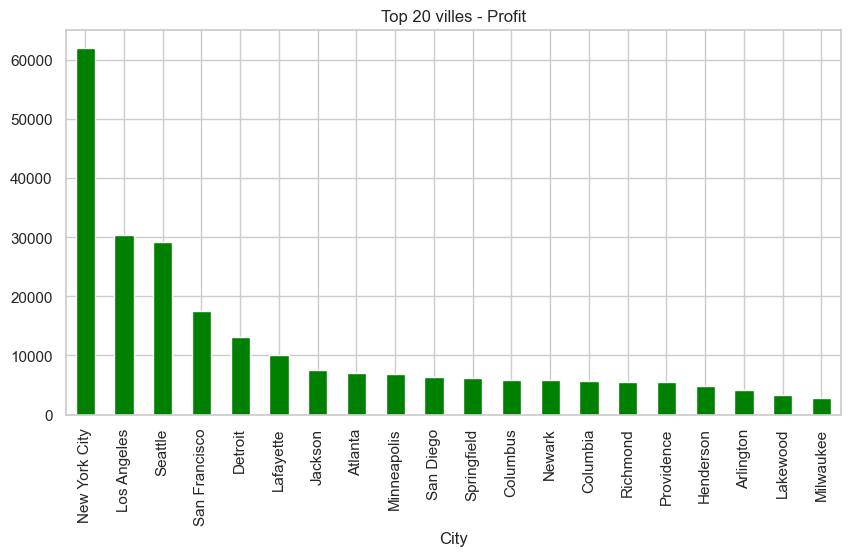

In [12]:
top_cities_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)
top_cities_profit.plot(kind="bar", color="green")
plt.title("Top 20 villes - Profit")
plt.show()

Top 20 clients (Ventes)

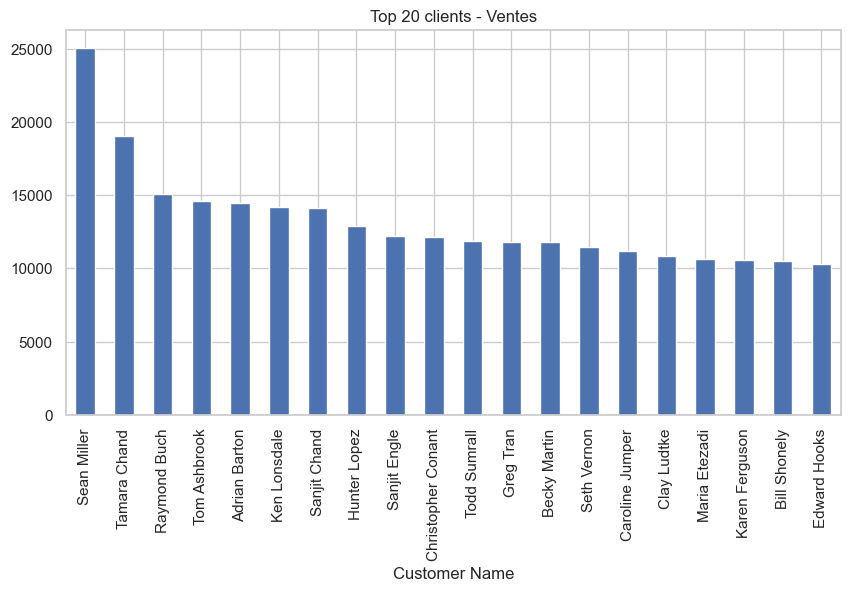

In [13]:
top_customers_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)
top_customers_sales.plot(kind="bar")
plt.title("Top 20 clients - Ventes")
plt.show()

Pareto ventes clients

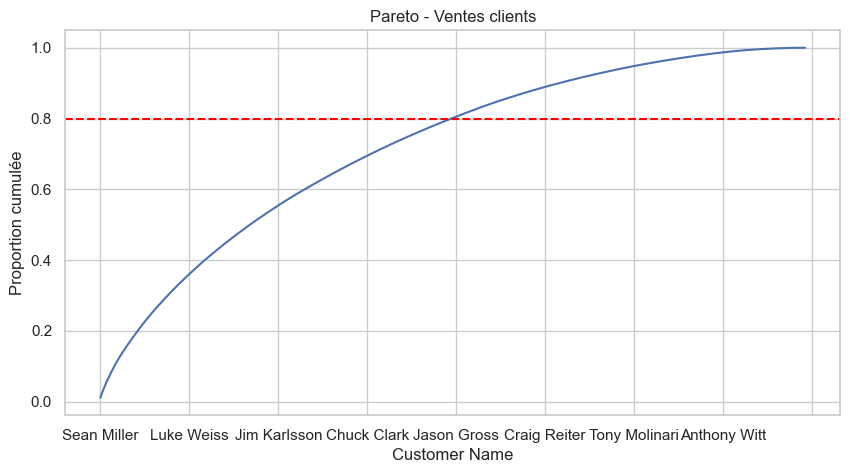

In [14]:
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
cum_sales = customer_sales.cumsum() / customer_sales.sum()
cum_sales.plot()
plt.axhline(0.8, color="red", linestyle="--")
plt.title("Pareto - Ventes clients")
plt.ylabel("Proportion cumulée")
plt.show()

## Conclusions stratégiques

### États à prioriser

Les analyses montrent qu’il est important de concentrer les efforts sur les États qui combinent à la fois un bon niveau de ventes et une rentabilité positive et stable. À l’inverse, certains États affichent un volume de ventes élevé mais génèrent peu ou pas de profit, voire des pertes. Ces zones doivent être analysées plus en profondeur avant tout investissement marketing supplémentaire.

### Villes stratégiques

Toutes les villes ne contribuent pas de la même manière à la performance globale. Il est plus pertinent de se concentrer sur les villes réellement rentables plutôt que sur celles qui génèrent simplement beaucoup de ventes. Les villes déficitaires ou peu rentables devraient voir les investissements réduits ou réévalués afin d’optimiser les ressources.

### Clients clés

L’analyse confirme le principe de Pareto : une petite proportion de clients génère la majorité du profit. Ces clients doivent être considérés comme stratégiques pour l’entreprise. Il est recommandé de mettre en place des actions de fidélisation, des offres personnalisées et éventuellement des programmes VIP afin de renforcer leur engagement et maximiser leur valeur sur le long terme.

### Produits

Tous les produits ne contribuent pas de manière égale à la rentabilité. Certains produits, bien que populaires en volume de vente, présentent des marges faibles. Il est donc nécessaire d’optimiser le portefeuille produit en réduisant l’impact des articles peu rentables et en mettant l’accent sur ceux qui génèrent un meilleur retour financier.
